In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/matches.csv")

[rows, cols] = df.shape
print(df.info())
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   match_id    380 non-null    int64  
 1   date        380 non-null    object 
 2   matchday    380 non-null    int64  
 3   home_team   380 non-null    object 
 4   away_team   380 non-null    object 
 5   home_goals  350 non-null    float64
 6   away_goals  350 non-null    float64
 7   winner      350 non-null    object 
 8   status      380 non-null    object 
 9   season      380 non-null    object 
dtypes: float64(2), int64(2), object(6)
memory usage: 29.8+ KB
None


,match_id,matchday,home_goals,away_goals
count,380.000000,380.000000,350.000000,350.000000
mean,544400.500000,19.500000,1.557143,1.128571
std,109.840794,10.980313,1.199758,0.971240
min,544211.000000,1.000000,0.000000,0.000000
25%,544305.750000,10.000000,1.000000,0.000000
50%,544400.500000,19.500000,1.000000,1.000000
75%,544495.250000,29.000000,2.000000,2.000000
max,544590.000000,38.000000,6.000000,5.000000


In [11]:
#12/5/2026

df["winner"].value_counts()

winner
HOME_TEAM    169
AWAY_TEAM     93
DRAW          88
Name: count, dtype: int64

Here we can see our first real insight: Home teams win almost the double of times than they do away. I'll take a look to the average goals of every team comparing when they are home with when they are away.

In [12]:
print("Home goals average:", df["home_goals"].mean())
print("Away goals average:", df["away_goals"].mean())

Home goals average: 1.5571428571428572
Away goals average: 1.1285714285714286


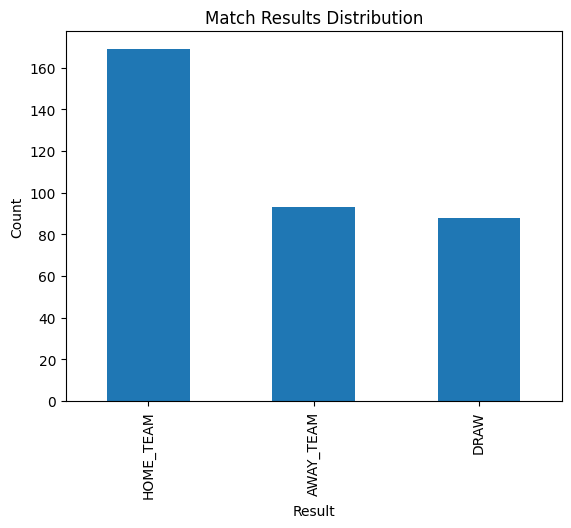

In [13]:
df["winner"].value_counts().plot(kind="bar")

plt.title("Match Results Distribution")
plt.xlabel("Result")
plt.ylabel("Count")

plt.show()

In [14]:
import sys
sys.path.append("..")

from src.standings import build_standings

table = build_standings(df)
print(table.head())

          team  matches_played  wins  draws  losses  goals_for  goals_against  \
0        Barça              38    30      1       7       91.0           31.0   
1  Real Madrid              38    24      5       9       70.0           33.0   
2   Villarreal              38    21      6      11       65.0           40.0   
3       Atleti              38    19      6      13       58.0           38.0   
4   Real Betis              38    13     15      10       54.0           43.0   

   goal_difference  points  
0             60.0      91  
1             37.0      77  
2             25.0      69  
3             20.0      63  
4             11.0      54  


*Standing table checked*

In [16]:
#13/5/2026 - Feature building checking:

from src.features import build_dataset

df = pd.read_csv("../data/matches.csv")
dataset = build_dataset(df, window=5)

print(dataset.shape)
print(dataset.columns)

(380, 25)
Index(['match_id', 'date', 'home_team', 'away_team', 'target',
       'home_points_last_5', 'home_winrate_last_5',
       'home_avg_goals_scored_last_5', 'home_avg_goals_conceded_last_5',
       'home_home_winrate', 'home_avg_home_goals',
       'home_avg_home_goals_conceded', 'home_away_winrate',
       'home_avg_away_goals', 'home_avg_away_goals_conceded',
       'away_points_last_5', 'away_winrate_last_5',
       'away_avg_goals_scored_last_5', 'away_avg_goals_conceded_last_5',
       'away_home_winrate', 'away_avg_home_goals',
       'away_avg_home_goals_conceded', 'away_away_winrate',
       'away_avg_away_goals', 'away_avg_away_goals_conceded'],
      dtype='object')


In [17]:
print(dataset.head())

   match_id                       date   home_team       away_team     target  \
0    544214  2025-08-15 17:00:00+00:00      Girona  Rayo Vallecano  AWAY_TEAM   
1    544220  2025-08-15 19:30:00+00:00  Villarreal     Real Oviedo  HOME_TEAM   
2    544216  2025-08-16 17:30:00+00:00    Mallorca           Barça  AWAY_TEAM   
3    544211  2025-08-16 19:30:00+00:00      Alavés         Levante  HOME_TEAM   
4    544219  2025-08-16 19:30:00+00:00    Valencia   Real Sociedad       DRAW   

   home_points_last_5  home_winrate_last_5  home_avg_goals_scored_last_5  \
0                   0             0.000000                          0.00   
1                   3             1.000000                          3.00   
2                   3             0.500000                          1.50   
3                   6             0.666667                          2.00   
4                   6             0.500000                          1.75   

   home_avg_goals_conceded_last_5  home_home_winrate  ..

In [ ]:
print(dataset.isnull().sum().sort_values(ascending=False))

In [ ]:
print(dataset.describe())

In [ ]:
dataset.groupby("home_team")["home_winrate"].mean().sort_values(ascending=False).head(10)

In [ ]:
print(dataset["home_winrate"].mean())
print(dataset["away_winrate"].mean())

In [ ]:
dataset.sample(3).T

In [ ]:
print(dataset.iloc[0])